In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random
import scipy
import functools

In [2]:
def ODE_system_solver(f, y0, t0, final_t, step = 1e-4):

    ts = np.arange(t0, final_t, step)
    ys = np.empty((len(ts), len(y0)), dtype=np.float32)
    ys[0] = y0

    for i, t in enumerate(ts[:-1]):
        ys[i + 1] = ys[i] + f(t, ys[i]) * step

    return ts, ys

In [3]:
class PDE:

    def __init__(self, u0):
        self.S_inicial = u0(torch.tensor([[0.0, 0.0, 0.0]]))[0, 0]
        self.S_left = 0.9
        self.u0 = u0

        self.mu_w = 1e-3
        self.mu_g = 1e-5
        self.S_wc = 0.2
        self.S_gr = 0.1

        def obj(S):
            S_tensor = torch.tensor(S)
            return self.f_prime(S_tensor) - (self.f(self.S_inicial) - self.f(S_tensor)) / (self.S_inicial - S_tensor)
        
        self.s_star = scipy.optimize.brentq(obj, self.S_inicial + 1e-4, self.S_left - 1e-4)
        self.sigma = (self.f(self.S_inicial) - self.f(self.s_star)) / (self.S_inicial - self.s_star)
        print(f"S_star: {self.s_star}, sigma: {self.sigma}")
        

    def k_rw(self, S):
        return ((S - self.S_wc) / (1 - self.S_wc - self.S_gr)) ** 4
    
    def k_rg(self, S):
        return ((1 - S - self.S_gr) / (1 - self.S_wc - self.S_gr)) ** 2
    
    def f(self, S):
        lambda_w = self.k_rw(S) / self.mu_w
        lambda_g = self.k_rg(S) / self.mu_g
        return lambda_w / (lambda_w + lambda_g)
    
    def rhs(self, t, y, dx = 0.01):
        F = np.empty(y.shape[0] + 1, dtype=np.float32)
        F[0] = self.f(self.S_left)
        F[1:] = self.f(y)
    
        return -(F[1:] - F[:-1]) / dx

    def f_prime(self, S):
        S = S.clone().detach().requires_grad_(True)
        f_val = self.f(S)
    
        return torch.autograd.grad(outputs=f_val, inputs=S, grad_outputs=torch.ones_like(f_val))[0]

    def f_tilde(self, S):
        return torch.where(S < self.s_star, self.f(self.S_inicial) + self.sigma * (S - self.S_inicial), self.f(S))
    

In [25]:
pdes = [
    PDE(lambda x: x[:, :1] * 0 + 0.0), PDE(lambda x: x[:, :1] * 0 + 0.2), PDE(lambda x: x[:, :1] * 0 + 0.4), PDE(lambda x: x[:, :1] * 0 + 0.1)
]

S_star: 0.8973277509211302, sigma: 1.112728476524353
S_star: 0.8965763151660897, sigma: 1.4320991039276123
S_star: 0.8952294290060808, sigma: 2.0094096660614014
S_star: 0.896998554469498, sigma: 1.2523610591888428


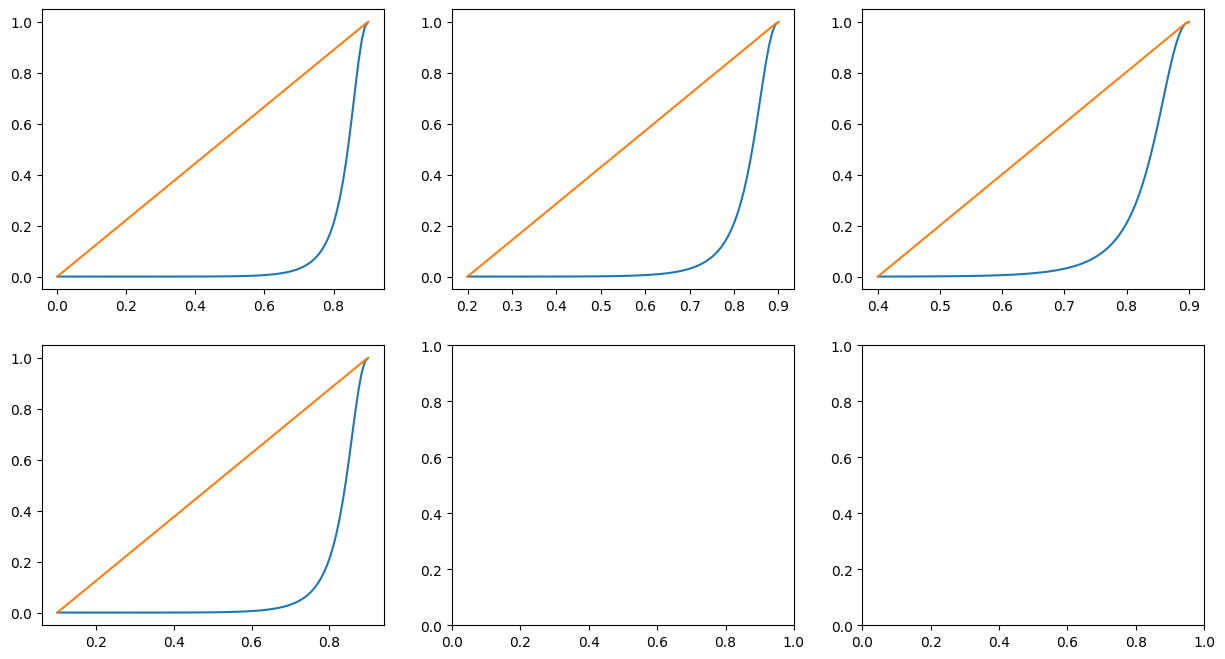

In [26]:
cols = min(3, len(pdes))
rows = np.ceil(len(pdes) / cols).astype(int)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = np.atleast_1d(axes).flatten()

for i, pde in enumerate(pdes):
    axes[i].plot(torch.linspace(pdes[i].S_inicial, pdes[i].S_left, 100), pdes[i].f(torch.linspace(pdes[i].S_inicial, pdes[i].S_left, 100)))
    axes[i].plot(torch.linspace(pdes[i].S_inicial, pdes[i].S_left, 100), pdes[i].f_tilde(torch.linspace(pdes[i].S_inicial, pdes[i].S_left, 100)).flatten())

In [27]:
L = 1.0
Nx = 100
dx = L / Nx
u = 1e-6
phi = 0.2

dt = 150.0 / (phi / u)
T_max = 150000 / (phi / u)
Nt = np.ceil(T_max / dt)

N_plot = 5000

idxs_t = np.random.randint(low=0, high=Nt, size=N_plot)
idxs_x = np.random.randint(low=0, high=Nx, size=N_plot)

C:\Users\Ivo\AppData\Local\Temp\ipykernel_8856\342702546.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ys[0] = y0


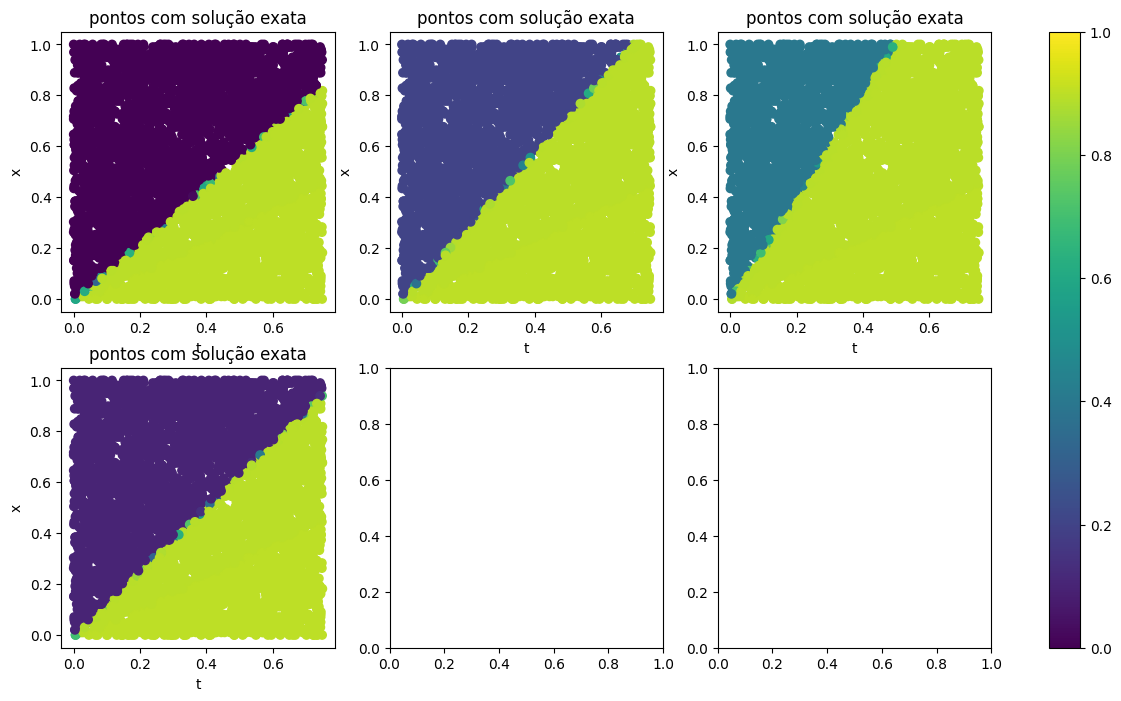

In [28]:
cols = min(3, len(pdes))
rows = np.ceil(len(pdes) / cols).astype(int)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = np.atleast_1d(axes).flatten()

uss = list()

for i, pde in enumerate(pdes):
    xs = torch.linspace(0, L, Nx)
    S0 = pde.u0(torch.column_stack((torch.zeros((Nx, 2)), xs.reshape(-1, 1)))).flatten()
    
    ts, us = ODE_system_solver(functools.partial(pde.rhs, dx=dx), S0, 0, T_max, dt)
    uss.append(us)
    
    X_plot = np.stack((ts[idxs_t], xs[idxs_x]), axis=1)
    u_plot = us[idxs_t, idxs_x]

    sc = axes[i].scatter(X_plot[:, 0], X_plot[:, 1], c=u_plot, cmap="viridis", vmin=0, vmax=1)
    axes[i].set_xlabel('t')
    axes[i].set_ylabel('x')
    axes[i].set_title('pontos com solução exata')
    
cbar = fig.colorbar(sc, ax=axes, orientation='vertical')

In [8]:
def sample_points(N_colocacao, N_contorno, N_inicial, max_t = T_max):
    X_colocacao = torch.cat([
        torch.randint(len(pdes), (N_colocacao, 1)),
        (1 - torch.rand(N_colocacao, 1)) * max_t,
        torch.rand(N_colocacao, 1)
    ], dim = 1)

    X_contorno = torch.cat([
        torch.randint(len(pdes), (N_contorno, 1)),
        (1 - torch.rand(N_contorno, 1)) * max_t, 
        torch.zeros(N_contorno, 1)
    ], dim = 1)

    X_inicial = torch.cat([
        torch.randint(len(pdes), (N_inicial, 1)),
        torch.zeros(N_inicial, 1),
        torch.rand(N_inicial, 1)
    ], dim = 1)

    return X_colocacao, X_contorno, X_inicial

def replace_least_error_points(points, new_points, errors):

    N_todos = points.shape[0]
    N_novos = new_points.shape[0]
    N_resto = N_todos - N_novos
    
    idxs = np.argpartition(-errors.detach().numpy(), N_resto, axis=0).flatten()
    idxs = idxs[:N_resto]

    return torch.cat((points[idxs], new_points), axis=0)    

def resample_ozanski(X_colocacao, X_contorno, X_inicial, model, perc=0.15, perc_boundary=0.1, lambda_1=0.1, max_t = T_max):

    X_todos = torch.cat((X_contorno, X_inicial, X_colocacao), dim=0).requires_grad_(True)
    
    N_colocacao = X_colocacao.shape[0]
    N_contorno = X_contorno.shape[0]
    N_inicial = X_inicial.shape[0]

    y_fake = model(X_todos)
    y_fake_contorno = y_fake[0:N_contorno, :]
    y_fake_inicial = y_fake[N_contorno:N_contorno + N_inicial, :]

    L_f, L_b1, L_b2 = pinn_loss(X_todos, y_fake, X_contorno, y_fake_contorno, X_inicial, y_fake_inicial, make_reduction=False)

    loss_contorno = L_f[0:N_contorno, :] + lambda_1 * L_b2
    loss_inicial = L_f[N_contorno:N_contorno + N_inicial, :] + lambda_1 * L_b1
    loss_colocacao = L_f[N_contorno + N_inicial:, :]

    X_novos_colocacao, X_novos_contorno, X_novos_inicial = sample_points(int(N_colocacao * perc), int(N_contorno * perc_boundary), int(N_inicial * perc_boundary), max_t)

    X_final_colocacao = replace_least_error_points(X_colocacao, X_novos_colocacao, loss_colocacao)
    X_final_contorno = replace_least_error_points(X_contorno, X_novos_contorno, loss_contorno)
    X_final_inicial = replace_least_error_points(X_inicial, X_novos_inicial, loss_inicial)

    return X_final_colocacao, X_final_contorno, X_final_inicial


In [9]:
def get_f_tildes(X_batch, y_fake):
    resultados = torch.empty(y_fake.shape[0], y_fake.shape[1])
    indices = X_batch[:, 0].long()
    
    for idx in indices.unique():
        mask = indices == idx
        resultados[mask] = pdes[int(idx)].f_tilde(y_fake[mask, :])

    return resultados

In [10]:
def get_x0s(X_batch):
    resultados = torch.empty(X_batch.shape[0], 1)
    indices = X_batch[:, 0].long()
    
    for idx in indices.unique():
        mask = indices == idx
        resultados[mask] = pdes[int(idx)].u0(X_batch[mask, :])

    return resultados

In [11]:
def get_uxms(X_batch):
    resultados = torch.empty(X_batch.shape[0], xm.shape[0])
    indices = X_batch[:, 0].long()
    
    for idx in indices.unique():
        mask = indices == idx
        resultados[mask] = pdes[int(idx)].u0(X_batch[mask, 1:])

    return resultados

In [12]:
def pinn_loss(X_batch, y_fake, X_contorno, y_contorno, X_inicial, y_inicial, lambda_1 = 1.5, make_reduction=True):
    
    dy_dX = torch.autograd.grad(y_fake, X_batch, grad_outputs=torch.ones_like(y_fake), create_graph=True, allow_unused=True)[0]

    # use f_tilde (https://arxiv.org/pdf/2112.14826)
    # f_val = pde.f_tilde(y_fake)
    f_val = get_f_tildes(X_batch, y_fake)
    df_dy = torch.autograd.grad(f_val, y_fake, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]
    
    dy_dt = dy_dX[:, 1:2]
    dy_dx = dy_dX[:, 2:]
    df_dx = df_dy * dy_dx # regra da cadeia

    if make_reduction:
        L_f = torch.mean((dy_dt + df_dx) ** 2)
        L_b1 = torch.mean((y_inicial - get_x0s(X_inicial)) ** 2)
        L_b2 = torch.mean((y_contorno - 0.9) ** 2)
    
        return L_f + lambda_1 * (L_b1 + L_b2)
    else:
        L_f = (dy_dt + df_dx) ** 2
        L_b1 = (y_inicial - get_x0s(X_inicial)) ** 2
        L_b2 = (y_contorno - 0.9) ** 2

        return L_f, L_b1, L_b2

In [13]:
class DeepONet(nn.Module):
    def __init__(self, input_dim, m, p=128, hidden_dim_trunk=128, hidden_dim_branch=265):
        super().__init__()
        
        self.trunk_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim_trunk),
            nn.Tanh(),
            nn.Linear(hidden_dim_trunk, hidden_dim_trunk),
            nn.Tanh(),
            nn.Linear(hidden_dim_trunk, hidden_dim_trunk),
            nn.Tanh(),
            nn.Linear(hidden_dim_trunk, hidden_dim_trunk),
            nn.Tanh(),
            nn.Linear(hidden_dim_trunk, p),
        )

        self.branch_net = nn.Sequential(
            nn.Linear(m, hidden_dim_branch),
            nn.Tanh(),
            nn.Linear(hidden_dim_branch, hidden_dim_branch),
            nn.Tanh(),
            nn.Linear(hidden_dim_branch, hidden_dim_branch),
            nn.Tanh(),
            nn.Linear(hidden_dim_branch, p),
        )

        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, z):
        uxms = get_uxms(z)
        bp = self.branch_net(uxms)
        tp = self.trunk_net(z[:, 1:])
        return torch.sum(tp * bp, dim=1, keepdim=True) + self.bias

In [15]:
N_colocacao = 10000
N_contorno = 1000
N_inicial = 1000

# pontos usados (escolhidos aleatoriamente a cada passo de treino)
X_colocacao, X_contorno, X_inicial = sample_points(N_colocacao, N_contorno, N_inicial)

batch_size = 256
batch_contorno = batch_size // 10
batch_inicial = batch_size // 10
batch_colocacao = batch_size - batch_contorno - batch_inicial

m = 1
p = 96
xm = torch.linspace(0.0, 1.0, m).reshape(-1, 1)

PINN_model = DeepONet(2, m, p, 64, 128)

n_iter = 30000
lr = 3e-4
optimizer = optim.Adam(PINN_model.parameters(), lr=lr)

# a cada quantas iterações vamos alterar os pontos usados
N_change_points = 75

todas_loss = []

In [16]:
for it in range(n_iter):

    X_batch_colocacao = X_colocacao[torch.randint(0, N_colocacao, (batch_colocacao,))]
    X_batch_contorno = X_contorno[torch.randint(0, N_contorno, (batch_contorno,))]
    X_batch_inicial = X_inicial[torch.randint(0, N_inicial, (batch_inicial,))]
    X_batch = torch.cat((X_batch_contorno, X_batch_inicial, X_batch_colocacao), dim=0).requires_grad_(True)

    y_fake = PINN_model(X_batch)
    
    y_fake_contorno = y_fake[0:batch_contorno, :]
    y_fake_inicial = y_fake[batch_contorno:batch_contorno + batch_inicial, :]
    
    L_PINN = pinn_loss(X_batch, y_fake, X_batch_contorno, y_fake_contorno, X_batch_inicial, y_fake_inicial)
    
    optimizer.zero_grad()
    L_PINN.backward()
    optimizer.step()

    if it % N_change_points == 0:
        todas_loss.append(L_PINN.item())
        X_colocacao, X_contorno, X_inicial = resample_ozanski(X_colocacao, X_contorno, X_inicial, PINN_model)
    
    if (it + 1) % (n_iter // 10) == 0:
        print(f"Iter {it+1}: L_PINN={L_PINN.item():.10f}")

Iter 3000: L_PINN=0.1147746146
Iter 6000: L_PINN=0.1281506866
Iter 9000: L_PINN=0.1453370303
Iter 12000: L_PINN=0.1286845654
Iter 15000: L_PINN=0.1117638052
Iter 18000: L_PINN=0.3662679195
Iter 21000: L_PINN=0.0560829006
Iter 24000: L_PINN=0.0703569800
Iter 27000: L_PINN=0.0537571236
Iter 30000: L_PINN=0.0665347055


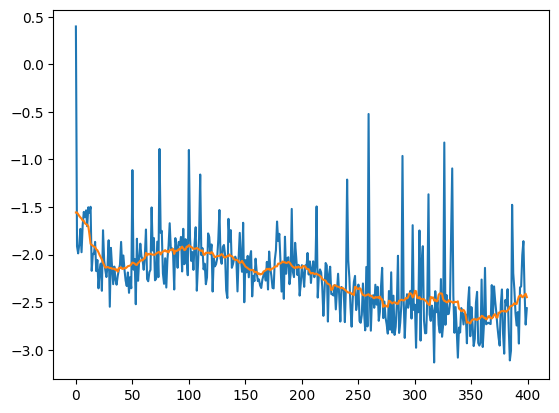

In [40]:
plt.plot(np.log(todas_loss))
plt.plot(scipy.ndimage.uniform_filter1d(np.log(todas_loss), size=25))
plt.show()

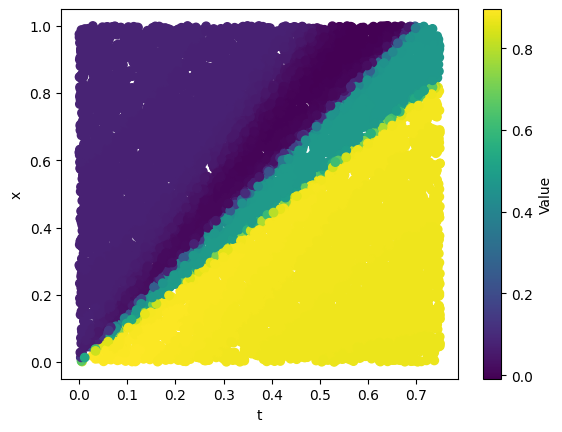

In [32]:
# x_plot = torch.cat((X_colocacao, X_inicial, X_contorno))
# x_plot = x_plot[x_plot[:, 0] == 2]

x_plot = torch.cat([
    torch.zeros((N_colocacao, 1)) + 3,
    (1 - torch.rand(N_colocacao, 1)) * T_max,
    torch.rand(N_colocacao, 1)
], dim = 1)


y_pred = PINN_model(x_plot).detach().numpy()
x_plot = x_plot.detach().numpy()

plt.scatter(x_plot[:, 1], x_plot[:, 2:], c=y_pred, cmap="viridis")
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.show()

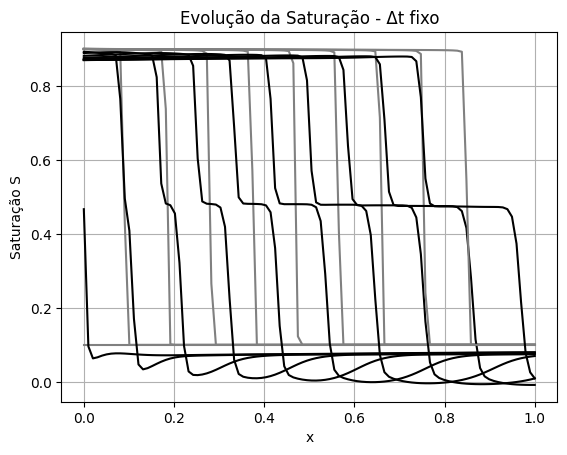

In [34]:
for idx, t in enumerate(ts[::100]):
    X = torch.tensor(np.stack([np.full(xs.shape, 3), np.full(xs.shape, t), xs], axis=1), dtype=torch.float32)
    S = PINN_model(X).detach().cpu().numpy()

    plt.plot(xs, uss[3][idx * 100, :], color="gray")
    plt.plot(xs, S, color="black")

plt.xlabel('x')
plt.ylabel('Saturação S')
plt.title('Evolução da Saturação - Δt fixo')
# plt.legend()
plt.grid(True)
plt.show()